In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
def h(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = r2 - r1
    return pref * (r1[0] + r2[0]) * d[1] - lam * np.sqrt(np.sum(d**2))

In [3]:
def g12(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = pt2 - pt1 + 1.5
    d %= 1
    d -= 0.5
    lambd = lam * d / np.sqrt(np.sum(d**2))
    g1x = pref * d[1] - lambd[0]
    g1y = -pref * (r1[0] + r2[0]) - lambd[1]
    g2x = pref * d[1] - lambd[0]
    g2y = pref * (r1[0] + r2[0]) - lambd[1]
    return np.array([g1x, g1y]), np.array([g2x, g2y])

In [4]:
def getNumericalOverlapForce(m):
    eps = 1e-6
    m.updateNeighbors(0)
    OA0 = m.functional(h)[0]
    dA = np.zeros(m.getNumVertices() * 2)
    pos0 = m.getPositions()
    for i in range(m.getNumVertices()):
        for j in range(2):
            positions = pos0.copy()
            positions[2 * i + j] += eps
            m.setPositions(positions)
            m.updateNeighbors(0)
            dA[2 * i + j] = (m.functional(h)[0] - OA0) / eps
    m.setPositions(pos0.copy())
    return -dA

<Figure size 640x480 with 0 Axes>

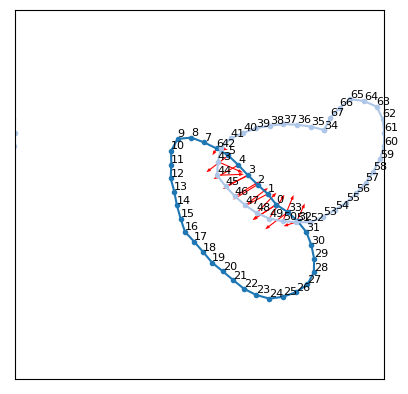

In [5]:
lam = 0.01
pref = 1
numPolygons = 2
n = 34
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
#m.setPositions((m.getPositions() + 0.5) % 1)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
# Now you have dA, can you draw arrows on the vertices?
ax = m.draw(numbering = True, forces = force, arrowColor = 'r')

In [6]:
m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = 2000)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
force = m.getConstrainedForce(force)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


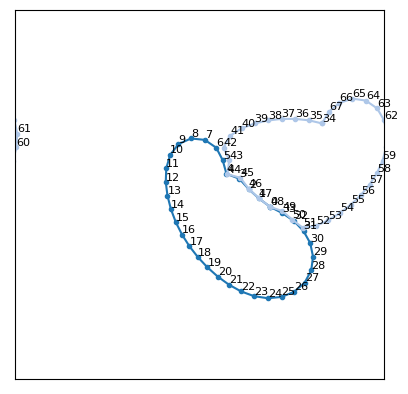

In [7]:
ax = m.draw(numbering = True, forces = force, arrowColor = 'r')

In [8]:
np.max(np.abs(force))

0.0041768860645148495

In [10]:
# I think this is working properly. Perhaps even better than I thought
# it would.